# find blood files

In [32]:
from regformer.utils.utils import train_test_split_adata
import numpy as np
import pandas as pd


stat_df = pd.read_csv('/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/CFM/examples/result/organs_stat.csv')
df = stat_df[stat_df.species == 'Homo sapiens']
tissue = 'blood'
df = df[df.tissue == tissue]
df
# lmdb_path = '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/CFM/data/lmdb/blood/blood.db'
# # map_size = int(10000e9)
# files = df['file'].values

,file,species,tissue,num_cells,num_genes
32,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,17308,36406
42,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,4232,33155
96,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,20727,33105
126,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,14783,17374
151,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,7750,24439
160,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,50115,58482
161,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,7750,24880
191,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,33415,33105
192,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,125117,30695
193,/home/share/huadjyin/home/s_qiuping1/workspace...,Homo sapiens,blood,647366,24677


In [3]:
df['num_cells'].sum()

9400351

In [9]:
files = df['file']
target_names = [f.split('/')[-1] for f in files]

import os

def find_files_by_name(root_dir, target_names):
    matched_files = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename in target_names:
                full_path = os.path.join(dirpath, filename)
                matched_files.append(full_path)
    return matched_files

matched_files = find_files_by_name('/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data', target_names)
matched_files

['/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_1/983d5ec9-40e8-4512-9e65-a572a9c486cb.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_1/ae5341b8-60fb-4fac-86db-86e49ee66287.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_1/21d3e683-80a4-4d9b-bc89-ebb2df513dde.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_1/96a3f64b-0ee9-40d8-91e9-813ce38261c9.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_1/ea786a06-5855-48b7-80d7-0313a21a2044.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_4/ed5d841d-6346-47d4-ab2f-7119ad7e3a35.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/data/cell_gene/data/subdir_4/19e46756-9100-4e01-8b0e-23b557558a4c.h5ad',
 '/home/share/huadjyin/home/s_qiuping1/workspace/omics_model/d

In [35]:
import scanpy as sc
import os
path = '/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/' #train 1156249, val: 289083
files = [path + f for f in os.listdir(path)]

def get_cells_number(adata_path):
    adata = sc.read_h5ad(adata_path, backed='r')
    cells = adata.obs.shape[0]
    adata.file.close()
    return cells

num = 0
for f in files:
    num = get_cells_number(f)
    print(f, num)

/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/3241c34f-581a-4de3-81fe-28e3de182680.h5ad 1938
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/8a554710-08bc-4005-87cd-da9675bdc2e7.h5ad 847
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/9c1b5626-58df-4401-ae7b-f66d068c1551.h5ad 1545
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/59632ec0-6f10-48c6-af79-81024e84843e.h5ad 1550
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/30cd5311-6c09-46c9-94f1-71fe4b91813c.h5ad 25008
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/59b69042-47c2-47fd-ad03-d21beb99818f.h5ad 9828
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/c2a461b1-0c15-4047-9fcb-1f966fe55100.h5ad 19438
/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/01c93cf6-b695-4e30-a26e-121ae8b16a9e.h5ad 741
/home/share/huadjyin/home/s_qiup

# stat the max length of nonzero genes

In [2]:
import os
import scanpy as sc
import numpy as np

def find_max_expressed_genes(data_dir):
    max_genes = 0
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".h5ad"):
                path = os.path.join(root, file)
                print(f"Processing: {path}")
                adata = sc.read_h5ad(path)

                # 如果是稀疏矩阵，使用 .X.getnnz(axis=1)；否则用 np.count_nonzero
                if hasattr(adata.X, 'getnnz'):
                    gene_counts = adata.X.getnnz(axis=1)
                else:
                    gene_counts = np.count_nonzero(adata.X, axis=1)

                max_in_file = gene_counts.max()
                max_genes = max(max_genes, max_in_file)
            print(f"Max expressed genes in {file}: {max_in_file}")

    return max_genes


numbers = find_max_expressed_genes('/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/')
print(numbers)

Processing: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/3241c34f-581a-4de3-81fe-28e3de182680.h5ad
Max expressed genes in 3241c34f-581a-4de3-81fe-28e3de182680.h5ad: 2954
Processing: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/8a554710-08bc-4005-87cd-da9675bdc2e7.h5ad
Max expressed genes in 8a554710-08bc-4005-87cd-da9675bdc2e7.h5ad: 6999
Processing: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/9c1b5626-58df-4401-ae7b-f66d068c1551.h5ad
Max expressed genes in 9c1b5626-58df-4401-ae7b-f66d068c1551.h5ad: 8089
Processing: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/59632ec0-6f10-48c6-af79-81024e84843e.h5ad
Max expressed genes in 59632ec0-6f10-48c6-af79-81024e84843e.h5ad: 5534
Processing: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/30cd5311-6c09-46c9-94f1-71fe4b91813c.h5ad
Max expressed genes in 30cd5311-6c09-46c9-94f1-71fe4b91813c.h5ad: 

Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/3241c34f-581a-4de3-81fe-28e3de182680.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/8a554710-08bc-4005-87cd-da9675bdc2e7.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/9c1b5626-58df-4401-ae7b-f66d068c1551.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/59632ec0-6f10-48c6-af79-81024e84843e.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/30cd5311-6c09-46c9-94f1-71fe4b91813c.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/59b69042-47c2-47fd-ad03-d21beb99818f.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/c2a461b1-0c15-4047-9fcb-1f966fe55100.h5ad
Reading: /home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/01c93cf6-b695-4e30-a26e-12

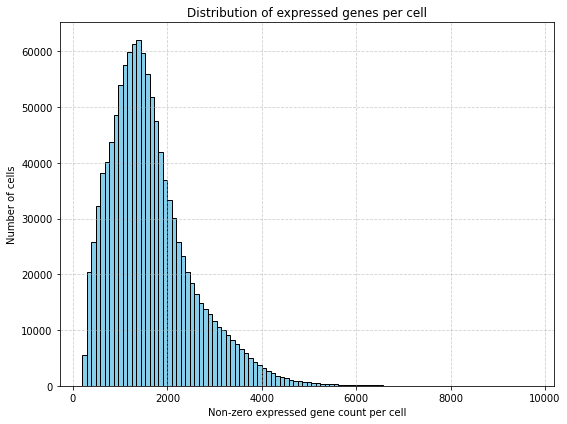

In [3]:
import os
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

def collect_gene_counts(data_dir):
    all_counts = []
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".h5ad"):
                path = os.path.join(root, file)
                print(f"Reading: {path}")
                adata = sc.read_h5ad(path)

                # 获取每个细胞中表达的基因数量
                if hasattr(adata.X, 'getnnz'):  # 如果是稀疏矩阵
                    counts = adata.X.getnnz(axis=1)
                else:  # 密集矩阵
                    counts = np.count_nonzero(adata.X, axis=1)

                all_counts.extend(counts)

    return np.array(all_counts)

def plot_distribution(counts):
    plt.figure(figsize=(8, 6))
    plt.hist(counts, bins=100, color='skyblue', edgecolor='black')
    plt.xlabel("Non-zero expressed gene count per cell")
    plt.ylabel("Number of cells")
    plt.title("Distribution of expressed genes per cell")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 替换成你的路径
data_path = "/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/"

counts = collect_gene_counts(data_path)
plot_distribution(counts)


In [42]:
import scanpy as sc

# 读取 h5ad 文件
# adata = sc.read_h5ad("/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/19e46756-9100-4e01-8b0e-23b557558a4c.h5ad")
# adata = sc.read_h5ad("/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/456e8b9b-f872-488b-871d-94534090a865.h5ad")
# adata = sc.read_h5ad("/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/de2c780c-1747-40bd-9ccf-9588ec186cee.h5ad")
# adata = sc.read_h5ad("/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/train/01c93cf6-b695-4e30-a26e-121ae8b16a9e.h5ad")
# adata = sc.read_h5ad("/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/d7d7e89c-c93a-422d-8958-9b4a90b69558.h5ad")
adata = sc.read_h5ad("/home/share/huadjyin/home/s_qiuping1/workspace/RegFormer/example/data/val/59b69042-47c2-47fd-ad03-d21beb99818f.h5ad")
adata

AnnData object with n_obs × n_vars = 9828 × 18445
    obs: 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'citation', 'doi', 'log1p', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'